In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/demographic/api_data_aadhar_demographic_500000_1000000.csv
/kaggle/input/demographic/api_data_aadhar_demographic_1500000_2000000.csv
/kaggle/input/demographic/api_data_aadhar_demographic_0_500000.csv
/kaggle/input/demographic/api_data_aadhar_demographic_2000000_2071700.csv
/kaggle/input/demographic/api_data_aadhar_demographic_1000000_1500000.csv


In [2]:
!mkdir -p src


In [3]:
%%writefile src/cleaning.py
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

EXPECTED_COLUMNS = {
    "date", "state", "district", "pincode", "demo_age_5_17", "demo_age_17_"
}

def load_and_merge(file_paths):
    """
    Load multiple CSV files and merge into a single DataFrame
    """
    dfs = []

    for path in file_paths:
        logging.info(f"Loading {path}")
        df = pd.read_csv(path)
        dfs.append(df)

    merged_df = pd.concat(dfs, ignore_index=True)
    logging.info(f"Merged dataset shape: {merged_df.shape}")

    return merged_df


def standardize_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df


def parse_dates(df):
    df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y", errors="coerce")
    return df


def clean_numeric_columns(df):
    numeric_cols = ["demo_age_5_17", "demo_age_17_"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def handle_missing_values(df):
    before = len(df)

    # Drop rows missing essential geo identifiers
    df = df.dropna(subset=["state", "district", "pincode"])

    # Fill demographic NaNs with 0 (safe assumption for counts)
    df["demo_age_5_17"] = df["demo_age_5_17"].fillna(0)
    df["demo_age_17_"] = df["demo_age_17_"].fillna(0)

    after = len(df)
    logging.info(f"Removed {before - after} rows with missing geo fields")

    return df


def validate_schema(df):
    missing = EXPECTED_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")


def clean_demographic(df):
    """
    Full cleaning pipeline
    """
    logging.info("Starting data cleaning pipeline")

    df = standardize_columns(df)
    validate_schema(df)
    df = parse_dates(df)
    df = clean_numeric_columns(df)
    df = handle_missing_values(df)

    # Remove negative values if any corruption
    df["demo_age_5_17"] = df["demo_age_5_17"].clip(lower=0)
    df["demo_age_17_"] = df["demo_age_17_"].clip(lower=0)

    # Remove impossible pincodes
    df = df[df["pincode"].astype(str).str.len().between(5, 6)]

    logging.info("Cleaning completed")

    return df.reset_index(drop=True)


Writing src/cleaning.py


In [4]:
!ls src


cleaning.py


In [5]:
!sed -n '1,5p' src/cleaning.py


import pandas as pd
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")



In [6]:
%%writefile src/feature_engineering.py
import numpy as np
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")


def add_dependency_ratio(df):
    """
    Child dependency ratio = children(5-17) / adults(18+)
    """
    df["dependency_ratio"] = df["demo_age_5_17"] / (df["demo_age_17_"] + 1e-9)

    return df


def add_migration_proxy(df):
    """
    Adult population month-on-month change per pincode as migration proxy
    """
    df = df.sort_values(["pincode", "date"])

    df["adult_change"] = (
        df.groupby("pincode")["demo_age_17_"]
        .diff()
    )

    return df


def add_population_totals(df):
    df["total_population_proxy"] = df["demo_age_5_17"] + df["demo_age_17_"]
    return df


def add_child_share(df):
    df["child_share"] = df["demo_age_5_17"] / (df["total_population_proxy"] + 1e-9)
    return df


def engineer_features(df):
    logging.info("Starting feature engineering")

    df = add_dependency_ratio(df)
    df = add_migration_proxy(df)
    df = add_population_totals(df)
    df = add_child_share(df)

    logging.info("Feature engineering completed")

    return df


Writing src/feature_engineering.py


In [7]:
%%writefile src/anomaly.py
import pandas as pd
from sklearn.ensemble import IsolationForest
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")


def prepare_pincode_features(df):
    agg = (
        df.groupby("pincode")[["demo_age_5_17", "demo_age_17_"]]
        .sum()
    )

    agg["dependency_ratio"] = agg["demo_age_5_17"] / (agg["demo_age_17_"] + 1e-9)

    return agg


def detect_anomalies(df, contamination=0.001):
    """
    Detect anomalous pincodes using Isolation Forest
    """
    logging.info("Preparing data for anomaly detection")

    pin_df = prepare_pincode_features(df)

    model = IsolationForest(
        n_estimators=300,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )

    logging.info("Training Isolation Forest")

    pin_df["anomaly_flag"] = model.fit_predict(
        pin_df[["dependency_ratio"]]
    )

    anomalies = pin_df[pin_df["anomaly_flag"] == -1]

    logging.info(f"Detected {len(anomalies)} anomalous pincodes")

    return anomalies.reset_index()


Writing src/anomaly.py


In [8]:
%%writefile src/migration.py
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")


def compute_migration_index(df):
    """
    Average adult population change per pincode
    """
    migration_index = (
        df.groupby("pincode")["adult_change"]
        .mean()
        .sort_values(ascending=False)
    )

    return migration_index


def top_migration_pincodes(df, n=20):
    logging.info(f"Computing top {n} migration hotspots")

    migration_index = compute_migration_index(df)

    return migration_index.head(n).reset_index(name="avg_monthly_adult_change")


Writing src/migration.py


In [9]:
%%writefile src/demographic_pipeline.py
import os
from cleaning import load_and_merge, clean_demographic
from feature_engineering import engineer_features
from anomaly import detect_anomalies
from migration import top_migration_pincodes
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# ============================
# CONFIGURE DATA FILE PATHS
# ============================

DATA_FILES = [
    "data/api_data_aadhar_demographic_0_500000.csv",
    "data/api_data_aadhar_demographic_500000_1000000.csv",
    "data/api_data_aadhar_demographic_1000000_1500000.csv",
    "data/api_data_aadhar_demographic_1500000_2000000.csv",
    "data/api_data_aadhar_demographic_2000000_2071700.csv"
]

OUTPUT_DIR = "outputs"


def run_pipeline():

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    logging.info("==== Aadhaar Demographic Pipeline Started ====")

    # Load
    df = load_and_merge(DATA_FILES)

    # Clean
    df = clean_demographic(df)

    # Feature Engineering
    df = engineer_features(df)

    # Anomaly Detection
    anomalies = detect_anomalies(df)

    # Migration hotspots
    migration_hotspots = top_migration_pincodes(df, n=50)

    # Save outputs
    processed_path = os.path.join(OUTPUT_DIR, "processed_demographic.csv")
    anomalies_path = os.path.join(OUTPUT_DIR, "anomalies.csv")
    migration_path = os.path.join(OUTPUT_DIR, "migration_hotspots.csv")

    df.to_csv(processed_path, index=False)
    anomalies.to_csv(anomalies_path, index=False)
    migration_hotspots.to_csv(migration_path, index=False)

    logging.info("Pipeline outputs saved:")
    logging.info(processed_path)
    logging.info(anomalies_path)
    logging.info(migration_path)

    logging.info("==== Pipeline Completed Successfully ====")


if __name__ == "__main__":
    run_pipeline()


Writing src/demographic_pipeline.py


In [10]:
!ls /kaggle/input


demographic


In [11]:
%%writefile src/demographic_pipeline.py
import os
from cleaning import load_and_merge, clean_demographic
from feature_engineering import engineer_features
from anomaly import detect_anomalies
from migration import top_migration_pincodes
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# ============================
# DATASET FILE PATHS (KAGGLE)
# ============================

DATA_FILES = [
    "/kaggle/input/demographic/api_data_aadhar_demographic_0_500000.csv",
    "/kaggle/input/demographic/api_data_aadhar_demographic_500000_1000000.csv",
    "/kaggle/input/demographic/api_data_aadhar_demographic_1000000_1500000.csv",
    "/kaggle/input/demographic/api_data_aadhar_demographic_1500000_2000000.csv",
    "/kaggle/input/demographic/api_data_aadhar_demographic_2000000_2071700.csv",
]

OUTPUT_DIR = "outputs"


def run_pipeline():

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    logging.info("==== Aadhaar Demographic Pipeline Started ====")

    # Load
    df = load_and_merge(DATA_FILES)

    # Clean
    df = clean_demographic(df)

    # Feature Engineering
    df = engineer_features(df)

    # Anomaly Detection
    anomalies = detect_anomalies(df)

    # Migration hotspots
    migration_hotspots = top_migration_pincodes(df, n=50)

    # Save outputs
    processed_path = os.path.join(OUTPUT_DIR, "processed_demographic.csv")
    anomalies_path = os.path.join(OUTPUT_DIR, "anomalies.csv")
    migration_path = os.path.join(OUTPUT_DIR, "migration_hotspots.csv")

    df.to_csv(processed_path, index=False)
    anomalies.to_csv(anomalies_path, index=False)
    migration_hotspots.to_csv(migration_path, index=False)

    logging.info("Pipeline outputs saved:")
    logging.info(processed_path)
    logging.info(anomalies_path)
    logging.info(migration_path)

    logging.info("==== Pipeline Completed Successfully ====")


if __name__ == "__main__":
    run_pipeline()


Overwriting src/demographic_pipeline.py


In [12]:
!python src/demographic_pipeline.py


2026-01-20 12:22:54,921 - INFO - ==== Aadhaar Demographic Pipeline Started ====
2026-01-20 12:22:54,921 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_0_500000.csv
2026-01-20 12:22:55,514 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_500000_1000000.csv
2026-01-20 12:22:56,030 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_1000000_1500000.csv
2026-01-20 12:22:56,547 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_1500000_2000000.csv
2026-01-20 12:22:57,015 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_2000000_2071700.csv
2026-01-20 12:22:57,203 - INFO - Merged dataset shape: (2071700, 6)
2026-01-20 12:22:57,222 - INFO - Starting data cleaning pipeline
2026-01-20 12:22:57,997 - INFO - Removed 0 rows with missing geo fields
2026-01-20 12:22:59,577 - INFO - Cleaning completed
2026-01-20 12:22:59,647 - INFO - Starting feature engineering
2026-01-20 12:23:00,115 - INFO - F

In [13]:
import pandas as pd

df = pd.read_csv("outputs/processed_demographic.csv")
anomalies = pd.read_csv("outputs/anomalies.csv")
migration_hotspots = pd.read_csv("outputs/migration_hotspots.csv")

print(df.shape)
df.head()


(2071700, 10)


,date,state,district,pincode,demo_age_5_17,demo_age_17_,dependency_ratio,adult_change,total_population_proxy,child_share
0,2025-12-20,100000,100000,100000,0,1,0.000000,NaN,1,0.000000
1,2025-12-23,100000,100000,100000,0,1,0.000000,0.0,1,0.000000
2,2025-03-01,Delhi,New Delhi,110001,74,437,0.169336,NaN,511,0.144814
3,2025-03-01,Delhi,New Delhi,110001,74,437,0.169336,0.0,511,0.144814
4,2025-06-01,Delhi,New Delhi,110001,44,321,0.137072,-116.0,365,0.120548


In [14]:
%%writefile src/cleaning.py
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

EXPECTED_COLUMNS = {
    "date", "state", "district", "pincode", "demo_age_5_17", "demo_age_17_"
}


def load_and_merge(file_paths):
    """
    Load multiple CSV files and merge into a single DataFrame
    """
    dfs = []

    for path in file_paths:
        logging.info(f"Loading {path}")
        df = pd.read_csv(path)
        dfs.append(df)

    merged_df = pd.concat(dfs, ignore_index=True)
    logging.info(f"Merged dataset shape: {merged_df.shape}")

    return merged_df


def standardize_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df


def parse_dates(df):
    df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y", errors="coerce")
    return df


def clean_numeric_columns(df):
    numeric_cols = ["demo_age_5_17", "demo_age_17_"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def handle_missing_values(df):
    before = len(df)

    # Drop rows missing essential geo identifiers
    df = df.dropna(subset=["state", "district", "pincode"])

    # Fill demographic NaNs with 0
    df["demo_age_5_17"] = df["demo_age_5_17"].fillna(0)
    df["demo_age_17_"] = df["demo_age_17_"].fillna(0)

    after = len(df)
    logging.info(f"Removed {before - after} rows with missing geo fields")

    return df


def validate_schema(df):
    missing = EXPECTED_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")


def remove_corrupted_geo_rows(df):
    """
    Remove rows where state or district are purely numeric (corrupted records)
    """
    before = len(df)

    df = df[~df["state"].astype(str).str.fullmatch(r"\d+")]
    df = df[~df["district"].astype(str).str.fullmatch(r"\d+")]

    after = len(df)
    logging.info(f"Removed {before - after} corrupted geo rows")

    return df


def validate_pincodes(df):
    """
    Keep only valid 5 or 6 digit numeric pincodes
    """
    before = len(df)

    df = df[df["pincode"].astype(str).str.match(r"^\d{5,6}$")]

    after = len(df)
    logging.info(f"Removed {before - after} invalid pincodes")

    return df


def clean_demographic(df):
    """
    Full cleaning pipeline
    """
    logging.info("Starting data cleaning pipeline")

    df = standardize_columns(df)
    validate_schema(df)
    df = parse_dates(df)
    df = clean_numeric_columns(df)
    df = handle_missing_values(df)

    # Remove negative values
    df["demo_age_5_17"] = df["demo_age_5_17"].clip(lower=0)
    df["demo_age_17_"] = df["demo_age_17_"].clip(lower=0)

    # Remove corrupted geographic rows
    df = remove_corrupted_geo_rows(df)

    # Validate pincodes
    df = validate_pincodes(df)

    logging.info("Cleaning completed")

    return df.reset_index(drop=True)


Overwriting src/cleaning.py


In [15]:
%%writefile src/feature_engineering.py
import numpy as np
import logging

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")


def add_dependency_ratio(df):
    """
    Child dependency ratio = children(5-17) / adults(18+)
    """
    df["dependency_ratio"] = df["demo_age_5_17"] / (df["demo_age_17_"] + 1e-9)
    return df


def add_migration_proxy(df):
    """
    Adult population month-on-month change per pincode as migration proxy
    """
    df = df.sort_values(["pincode", "date"])

    df["adult_change"] = (
        df.groupby("pincode")["demo_age_17_"]
        .diff()
    )

    # First month per pincode → no previous value → fill with 0
    df["adult_change"] = df["adult_change"].fillna(0)

    return df


def add_population_totals(df):
    df["total_population_proxy"] = df["demo_age_5_17"] + df["demo_age_17_"]
    return df


def add_child_share(df):
    df["child_share"] = df["demo_age_5_17"] / (df["total_population_proxy"] + 1e-9)
    return df


def engineer_features(df):
    logging.info("Starting feature engineering")

    df = add_dependency_ratio(df)
    df = add_migration_proxy(df)
    df = add_population_totals(df)
    df = add_child_share(df)

    logging.info("Feature engineering completed")

    return df


Overwriting src/feature_engineering.py


In [16]:
!python src/demographic_pipeline.py


2026-01-20 12:23:20,832 - INFO - ==== Aadhaar Demographic Pipeline Started ====
2026-01-20 12:23:20,832 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_0_500000.csv
2026-01-20 12:23:21,275 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_500000_1000000.csv
2026-01-20 12:23:21,711 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_1000000_1500000.csv
2026-01-20 12:23:22,106 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_1500000_2000000.csv
2026-01-20 12:23:22,497 - INFO - Loading /kaggle/input/demographic/api_data_aadhar_demographic_2000000_2071700.csv
2026-01-20 12:23:22,677 - INFO - Merged dataset shape: (2071700, 6)
2026-01-20 12:23:22,693 - INFO - Starting data cleaning pipeline
2026-01-20 12:23:23,440 - INFO - Removed 0 rows with missing geo fields
2026-01-20 12:23:25,554 - INFO - Removed 2 corrupted geo rows
2026-01-20 12:23:27,239 - INFO - Removed 0 invalid pincodes
2026-01-20 12:23:27,251 - 

In [17]:
df = pd.read_csv("outputs/processed_demographic.csv")
df.head()


,date,state,district,pincode,demo_age_5_17,demo_age_17_,dependency_ratio,adult_change,total_population_proxy,child_share
0,2025-03-01,Delhi,New Delhi,110001,74,437,0.169336,0.0,511,0.144814
1,2025-03-01,Delhi,New Delhi,110001,74,437,0.169336,0.0,511,0.144814
2,2025-06-01,Delhi,New Delhi,110001,44,321,0.137072,-116.0,365,0.120548
3,2025-09-01,Delhi,Central Delhi,110001,1,3,0.333333,-318.0,4,0.250000
4,2025-09-01,Delhi,New Delhi,110001,1,10,0.100000,7.0,11,0.090909


In [18]:
import pandas as pd

df = pd.read_csv("outputs/processed_demographic.csv")

print("Shape:", df.shape)
df.head()


Shape: (2071698, 10)


,date,state,district,pincode,demo_age_5_17,demo_age_17_,dependency_ratio,adult_change,total_population_proxy,child_share
0,2025-03-01,Delhi,New Delhi,110001,74,437,0.169336,0.0,511,0.144814
1,2025-03-01,Delhi,New Delhi,110001,74,437,0.169336,0.0,511,0.144814
2,2025-06-01,Delhi,New Delhi,110001,44,321,0.137072,-116.0,365,0.120548
3,2025-09-01,Delhi,Central Delhi,110001,1,3,0.333333,-318.0,4,0.250000
4,2025-09-01,Delhi,New Delhi,110001,1,10,0.100000,7.0,11,0.090909


In [19]:
df.describe()


,pincode,demo_age_5_17,demo_age_17_,dependency_ratio,adult_change,total_population_proxy,child_share
count,2.071698e+06,2.071698e+06,2.071698e+06,2.071698e+06,2.071698e+06,2.071698e+06,2.071698e+06
mean,5.278322e+05,2.347555e+00,2.144703e+01,2.319595e+07,-3.392234e+00,2.379458e+01,1.123105e-01
std,1.972930e+05,1.490356e+01,1.252498e+02,1.867742e+08,8.473913e+01,1.382000e+02,1.831305e-01
min,1.100010e+05,0.000000e+00,0.000000e+00,0.000000e+00,-1.616500e+04,0.000000e+00,0.000000e+00
25%,3.964690e+05,0.000000e+00,2.000000e+00,0.000000e+00,-3.000000e+00,3.000000e+00,0.000000e+00
50%,5.243220e+05,1.000000e+00,6.000000e+00,3.448276e-02,0.000000e+00,7.000000e+00,3.333333e-02
75%,6.955070e+05,2.000000e+00,1.500000e+01,1.875000e-01,2.000000e+00,1.700000e+01,1.578947e-01
max,8.554560e+05,2.690000e+03,1.616600e+04,2.400000e+10,1.349500e+04,1.694200e+04,1.000000e+00


In [20]:
state_dep = (
    df.groupby("state")[["demo_age_5_17", "demo_age_17_"]]
    .sum()
)

state_dep["dependency_ratio"] = (
    state_dep["demo_age_5_17"] / state_dep["demo_age_17_"]
)

state_dep_sorted = state_dep.sort_values("dependency_ratio", ascending=False)

state_dep_sorted.head(10)


,demo_age_5_17,demo_age_17_,dependency_ratio
state,,,
Ladakh,1375,4360,0.315367
Dadra and Nagar Haveli,1310,4723,0.277366
Puducherry,4089,21215,0.192741
Arunachal Pradesh,5783,30660,0.188617
Chandigarh,13133,70228,0.187005
Karnataka,264981,1430304,0.185262
Daman and Diu,234,1318,0.177542
Telangana,242259,1387649,0.174582
Lakshadweep,170,1006,0.168986


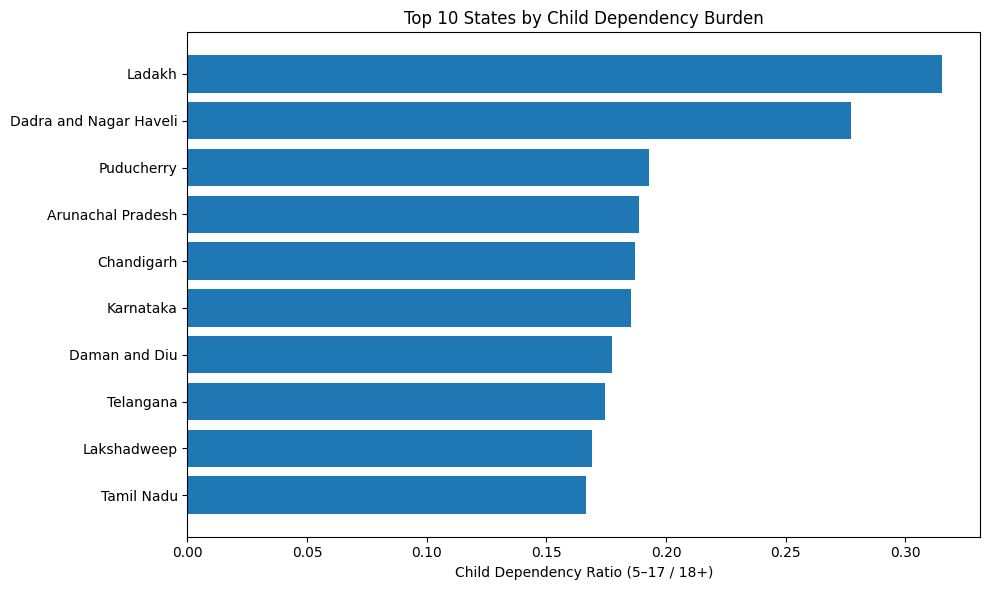

In [21]:
import matplotlib.pyplot as plt

top10 = state_dep_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10["dependency_ratio"])
plt.xlabel("Child Dependency Ratio (5–17 / 18+)")
plt.title("Top 10 States by Child Dependency Burden")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [22]:
df["adult_change"].describe()


count    2.071698e+06
mean    -3.392234e+00
std      8.473913e+01
min     -1.616500e+04
25%     -3.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      1.349500e+04
Name: adult_change, dtype: float64

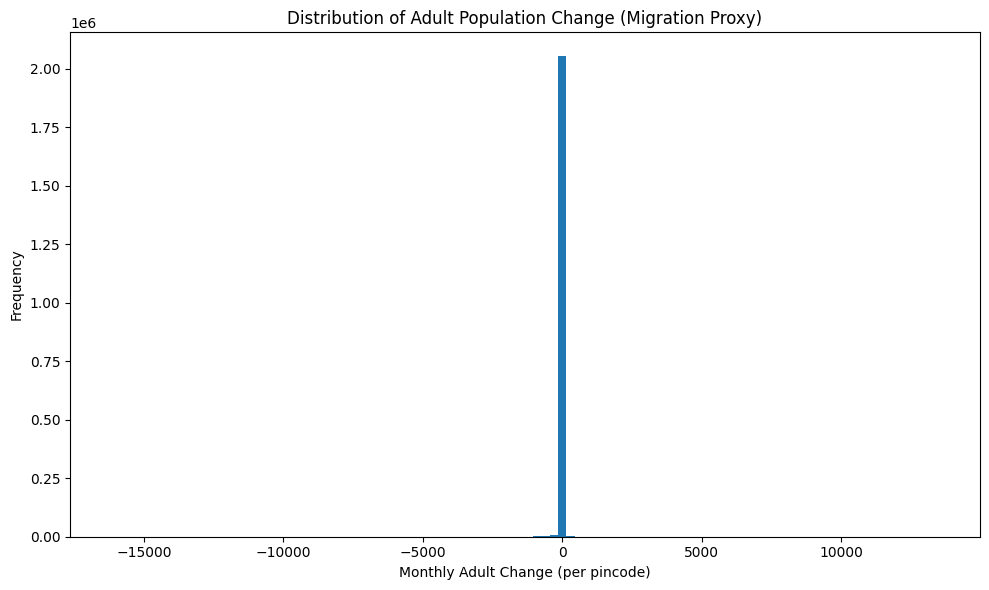

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df["adult_change"], bins=100)
plt.xlabel("Monthly Adult Change (per pincode)")
plt.ylabel("Frequency")
plt.title("Distribution of Adult Population Change (Migration Proxy)")
plt.tight_layout()
plt.show()


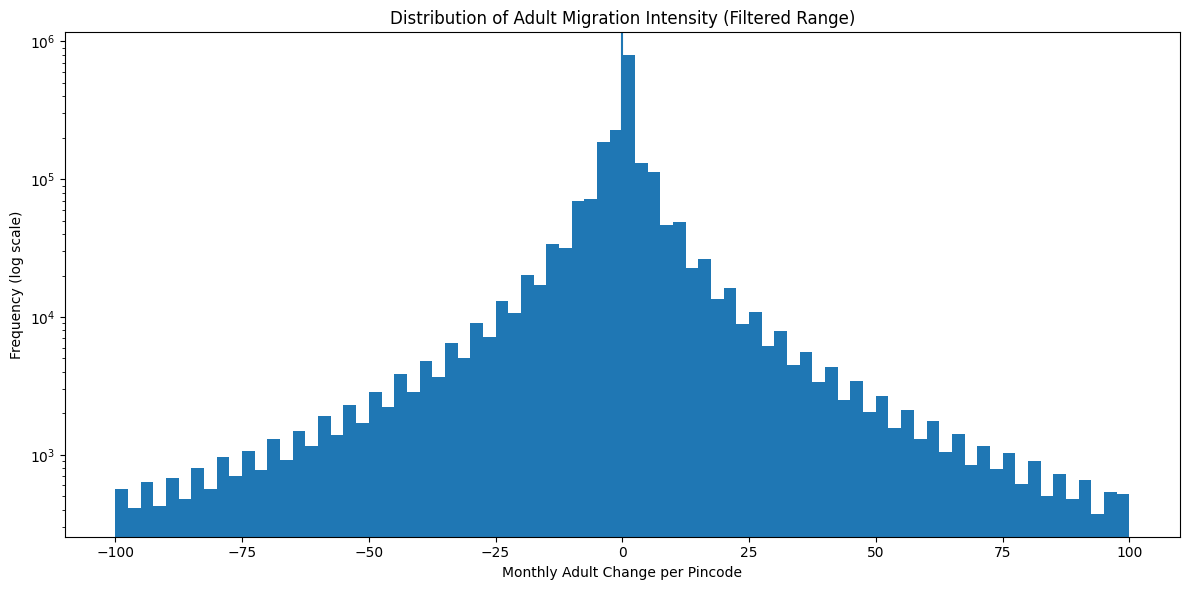

In [24]:
import matplotlib.pyplot as plt

# Focus on meaningful migration range
filtered = df[(df["adult_change"] >= -100) & (df["adult_change"] <= 100)]

plt.figure(figsize=(12,6))
plt.hist(filtered["adult_change"], bins=80)
plt.axvline(0)
plt.xlabel("Monthly Adult Change per Pincode")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Adult Migration Intensity (Filtered Range)")
plt.yscale("log")
plt.tight_layout()
plt.show()


In [25]:
migration_hotspots.head(10)


,pincode,avg_monthly_adult_change
0,641051,1.000000
1,627119,1.000000
2,413213,0.928571
3,445215,0.802326
4,261001,0.707865
5,243701,0.679012
6,122504,0.662791
7,431514,0.645161
8,243201,0.639535
9,444503,0.609589


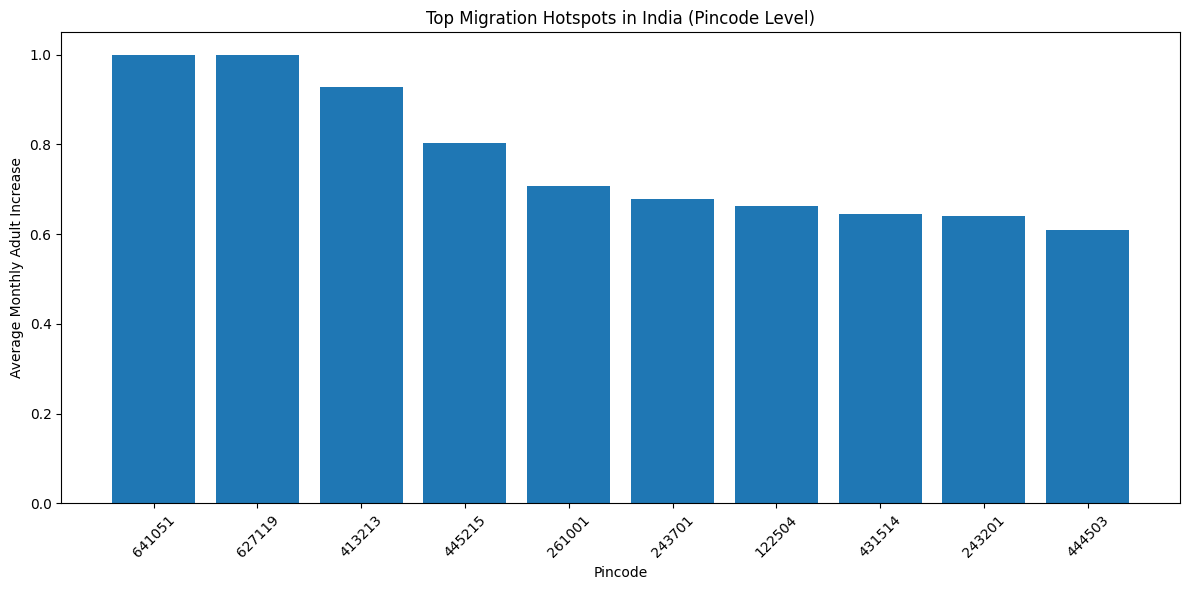

In [26]:
top_mig = migration_hotspots.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_mig["pincode"].astype(str), top_mig["avg_monthly_adult_change"])
plt.xlabel("Pincode")
plt.ylabel("Average Monthly Adult Increase")
plt.title("Top Migration Hotspots in India (Pincode Level)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
district_migration = (
    df.groupby(["state", "district"])["adult_change"]
      .mean()
      .reset_index(name="avg_monthly_adult_change")
      .sort_values("avg_monthly_adult_change", ascending=False)
)

district_migration.head(10)


,state,district,avg_monthly_adult_change
220,Delhi,North East Delhi,75.709443
567,Manipur,Bishnupur,60.983553
184,Chhattisgarh,Kawardha,37.969309
578,Manipur,Thoubal,37.483232
1061,West Bengal,Uttar Dinajpur,27.486522
533,Maharashtra,Gondiya,19.634783
519,Maharashtra,Aurangabad,17.090284
197,Chhattisgarh,Rajnandgaon,16.520231
564,Maharashtra,Washim,16.474217
186,Chhattisgarh,Kondagaon,16.022764


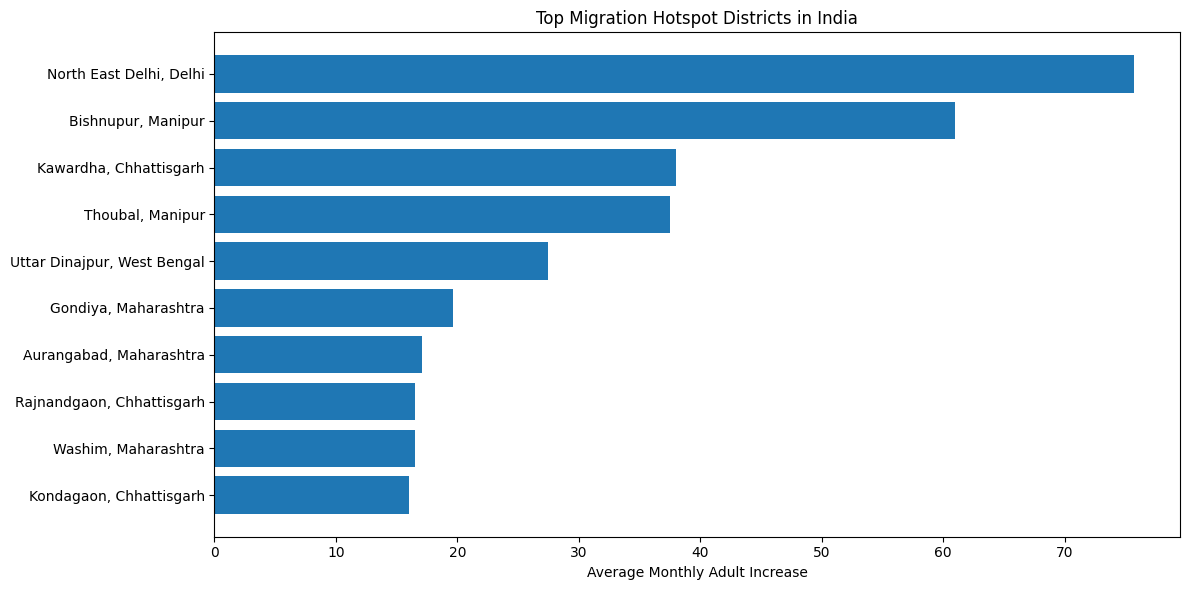

In [28]:
top_districts = district_migration.head(10)

plt.figure(figsize=(12,6))
plt.barh(
    top_districts["district"] + ", " + top_districts["state"],
    top_districts["avg_monthly_adult_change"]
)
plt.xlabel("Average Monthly Adult Increase")
plt.title("Top Migration Hotspot Districts in India")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [29]:
top_districts.to_csv("outputs/district_migration_hotspots.csv", index=False)


In [30]:
district_changes = district_migration["avg_monthly_adult_change"]

district_changes.describe()


count    1077.000000
mean       -7.701665
std        18.467467
min      -304.090909
25%        -9.136762
50%        -3.602685
75%        -0.851462
max        75.709443
Name: avg_monthly_adult_change, dtype: float64

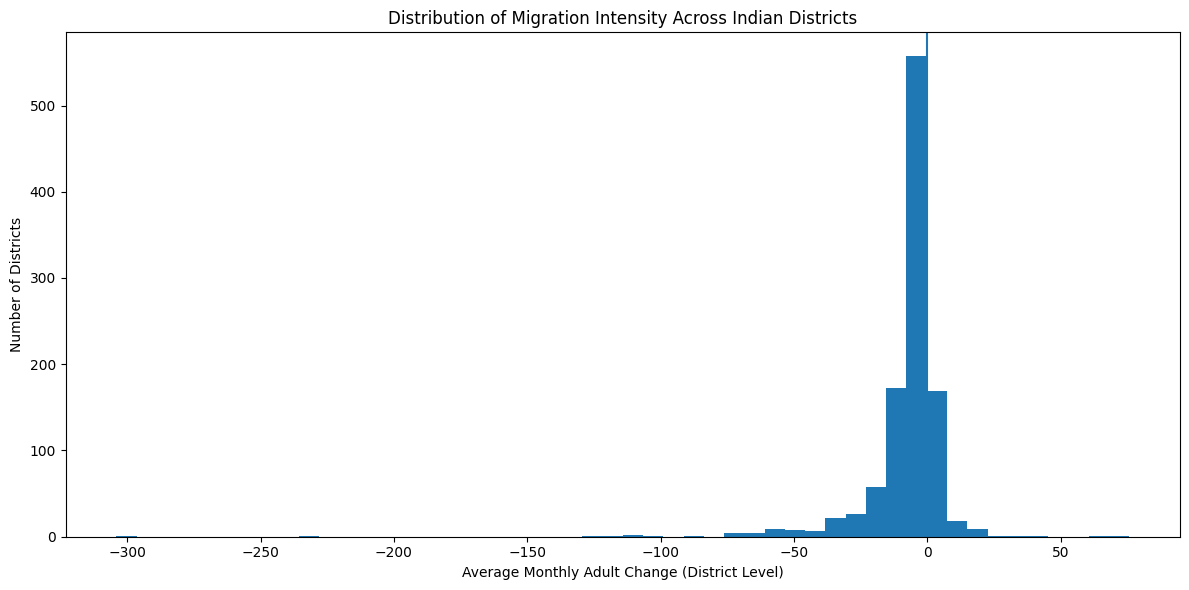

In [31]:
plt.figure(figsize=(12,6))
plt.hist(district_changes, bins=50)
plt.axvline(0)
plt.xlabel("Average Monthly Adult Change (District Level)")
plt.ylabel("Number of Districts")
plt.title("Distribution of Migration Intensity Across Indian Districts")
plt.tight_layout()
plt.show()


In [32]:
def classify_migration(x):
    if x > 10:
        return "High In-Migration"
    elif x > 2:
        return "Moderate In-Migration"
    elif x >= -2:
        return "Stable"
    elif x >= -10:
        return "Moderate Out-Migration"
    else:
        return "High Out-Migration"

district_migration["migration_category"] = district_migration["avg_monthly_adult_change"].apply(classify_migration)

district_migration["migration_category"].value_counts()


migration_category
Moderate Out-Migration    453
Stable                    299
High Out-Migration        241
Moderate In-Migration      56
High In-Migration          28
Name: count, dtype: int64

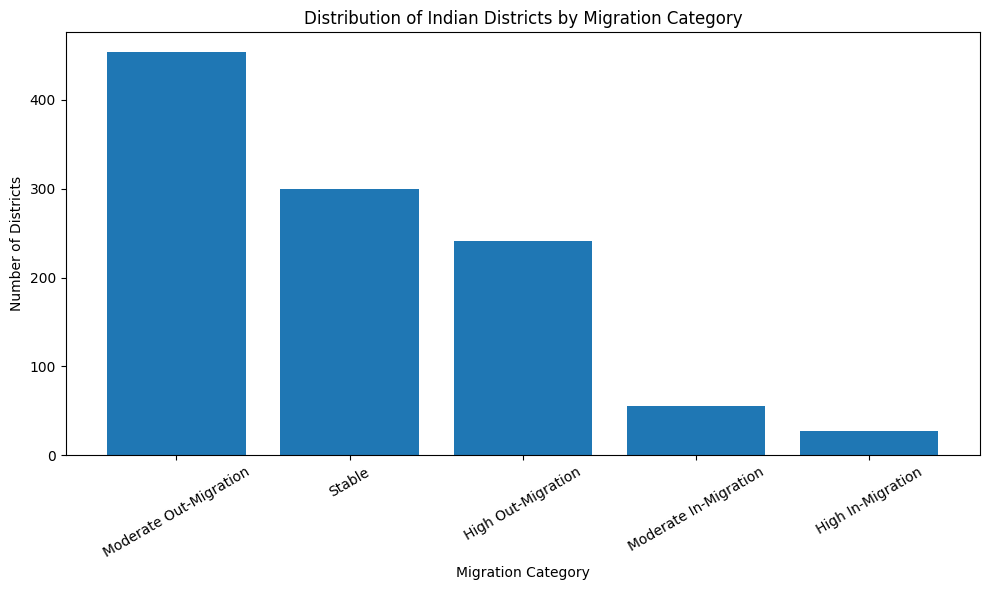

In [33]:
category_counts = district_migration["migration_category"].value_counts()

plt.figure(figsize=(10,6))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel("Migration Category")
plt.ylabel("Number of Districts")
plt.title("Distribution of Indian Districts by Migration Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [34]:
top_out = district_migration.sort_values("avg_monthly_adult_change").head(15)
top_out


,state,district,avg_monthly_adult_change,migration_category
1076,west Bengal,South 24 Parganas,-304.090909,High Out-Migration
950,Uttar Pradesh,Kushinagar *,-229.893939,High Out-Migration
1069,West bengal,South 24 Parganas,-122.222222,High Out-Migration
143,Bihar,Pashchim Champaran,-121.203233,High Out-Migration
536,Maharashtra,Hingoli *,-110.666667,High Out-Migration
1007,West Bangal,South 24 Parganas,-107.800000,High Out-Migration
1036,West Bengal,MALDA,-104.914894,High Out-Migration
216,Delhi,Najafgarh,-86.281690,High Out-Migration
1072,Westbengal,Howrah,-74.857143,High Out-Migration
526,Maharashtra,Chatrapati Sambhaji Nagar,-72.404908,High Out-Migration


In [35]:
top_in = district_migration.sort_values("avg_monthly_adult_change", ascending=False).head(15)
top_in


,state,district,avg_monthly_adult_change,migration_category
220,Delhi,North East Delhi,75.709443,High In-Migration
567,Manipur,Bishnupur,60.983553,High In-Migration
184,Chhattisgarh,Kawardha,37.969309,High In-Migration
578,Manipur,Thoubal,37.483232,High In-Migration
1061,West Bengal,Uttar Dinajpur,27.486522,High In-Migration
533,Maharashtra,Gondiya,19.634783,High In-Migration
519,Maharashtra,Aurangabad,17.090284,High In-Migration
197,Chhattisgarh,Rajnandgaon,16.520231,High In-Migration
564,Maharashtra,Washim,16.474217,High In-Migration
186,Chhattisgarh,Kondagaon,16.022764,High In-Migration


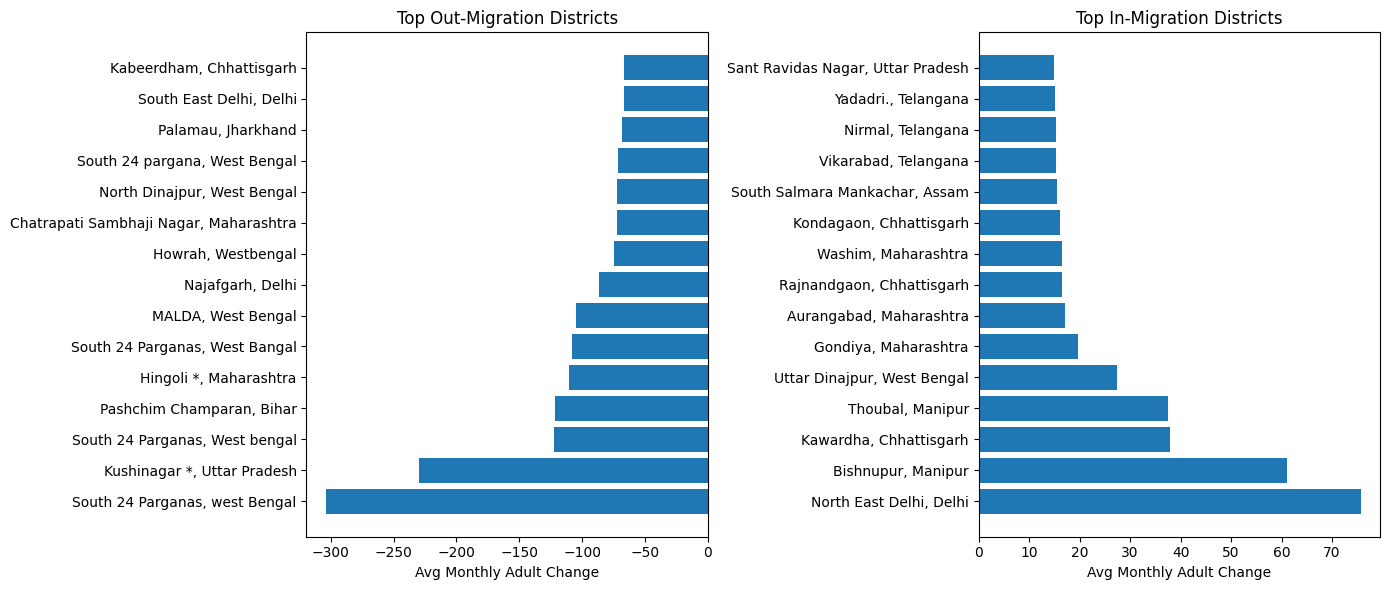

In [36]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.barh(top_out["district"] + ", " + top_out["state"], top_out["avg_monthly_adult_change"])
plt.title("Top Out-Migration Districts")
plt.xlabel("Avg Monthly Adult Change")

plt.subplot(1,2,2)
plt.barh(top_in["district"] + ", " + top_in["state"], top_in["avg_monthly_adult_change"])
plt.title("Top In-Migration Districts")
plt.xlabel("Avg Monthly Adult Change")

plt.tight_layout()
plt.show()


In [37]:
state_migration = (
    df.groupby("state")["adult_change"]
      .mean()
      .reset_index(name="avg_monthly_adult_change")
      .sort_values("avg_monthly_adult_change", ascending=False)
)

state_migration


,state,avg_monthly_adult_change
11,Dadra and Nagar Haveli,4.612308
48,Telangana,2.626586
41,Puducherry,0.720251
28,Lakshadweep,0.007692
52,Uttaranchal,0.000000
...,...,...
43,Puttenahalli,-35.000000
29,Madanapalle,-36.000000
59,West bengal,-51.256410
21,Jaipur,-60.500000


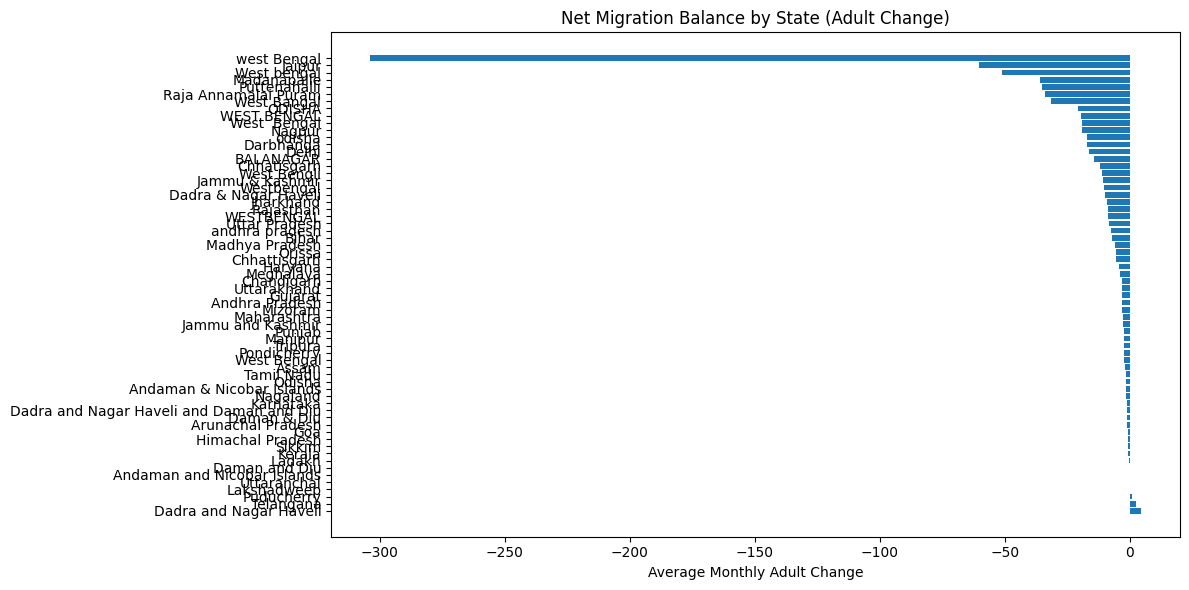

In [38]:
plt.figure(figsize=(12,6))
plt.barh(state_migration["state"], state_migration["avg_monthly_adult_change"])
plt.title("Net Migration Balance by State (Adult Change)")
plt.xlabel("Average Monthly Adult Change")
plt.tight_layout()
plt.show()


In [39]:
district_demo = (
    df.groupby(["state","district"])
      .agg({
          "adult_change":"mean",
          "child_share":"mean",
          "dependency_ratio":"mean"
      })
      .reset_index()
)
district_demo.head()


,state,district,adult_change,child_share,dependency_ratio
0,Andaman & Nicobar Islands,Andamans,-1.541401,0.007511,3.184713e+06
1,Andaman & Nicobar Islands,Nicobars,-2.250000,0.000000,0.000000e+00
2,Andaman & Nicobar Islands,South Andaman,-1.451282,0.012735,5.128205e+06
3,Andaman and Nicobar Islands,Nicobar,-1.304688,0.097382,5.468750e+07
4,Andaman and Nicobar Islands,North And Middle Andaman,-0.520710,0.041026,2.071006e+07


In [40]:
vulnerable = district_demo[
    (district_demo["adult_change"] < -10) &
    (district_demo["child_share"] > 0.2)
].sort_values("adult_change")

vulnerable.head(15)


,state,district,adult_change,child_share,dependency_ratio
919,Uttar Pradesh,Chandauli *,-46.000000,1.000000,1.000000e+09
574,Manipur,Kangpokpi,-32.333333,0.666667,6.666667e+08
862,Telangana,Medchal?malkajgiri,-29.363636,0.299571,1.818182e+08
573,Manipur,Kakching,-27.845070,0.205517,6.572770e+07
903,Uttar Pradesh,Baghpat *,-21.000000,0.333333,3.333333e+08
568,Manipur,Chandel,-18.784736,0.206046,6.457926e+07
864,Telangana,Medchal−malkajgiri,-15.325250,0.241709,1.526391e+08
328,Jammu and Kashmir,Budgam,-10.121008,0.321198,1.294118e+08


In [41]:
district_demo["stress_index"] = (
    (-district_demo["adult_change"]) * 0.5 +
    (district_demo["dependency_ratio"]) * 0.3 +
    (district_demo["child_share"]) * 0.2
)

stress_hotspots = district_demo.sort_values("stress_index", ascending=False).head(15)
stress_hotspots


,state,district,adult_change,child_share,dependency_ratio,stress_index
919,Uttar Pradesh,Chandauli *,-46.000000,1.000000,1.000000e+09,3.000000e+08
574,Manipur,Kangpokpi,-32.333333,0.666667,6.666667e+08,2.000000e+08
317,Jammu & Kashmir,Leh (ladakh),-4.333333,0.444444,4.444444e+08,1.333333e+08
59,Arunachal Pradesh,Leparada,-4.952381,0.333333,3.809524e+08,1.142857e+08
903,Uttar Pradesh,Baghpat *,-21.000000,0.333333,3.333333e+08,1.000000e+08
300,Himachal Pradesh,Lahaul and Spiti,-0.137255,0.284314,2.745098e+08,8.235294e+07
596,Mizoram,Khawzawl,-4.000000,0.288462,2.692308e+08,8.076923e+07
10,Andhra Pradesh,Ananthapur,-3.249836,0.335223,2.513158e+08,7.539474e+07
302,Himachal Pradesh,Lahul and Spiti,-0.286550,0.265692,2.397661e+08,7.192982e+07
56,Arunachal Pradesh,Kamle,-0.163265,0.290597,2.244898e+08,6.734694e+07


In [42]:
workload_state = (
    df.groupby("state")["demo_age_5_17"]
      .sum()
      .reset_index(name="children_needing_updates")
      .sort_values("children_needing_updates", ascending=False)
)

workload_state.head(10)


,state,children_needing_updates
50,Uttar Pradesh,790308
30,Madhya Pradesh,407098
6,Bihar,380023
2,Andhra Pradesh,321143
47,Tamil Nadu,315638
31,Maharashtra,273322
25,Karnataka,264981
45,Rajasthan,257224
57,West Bengal,242549
48,Telangana,242259


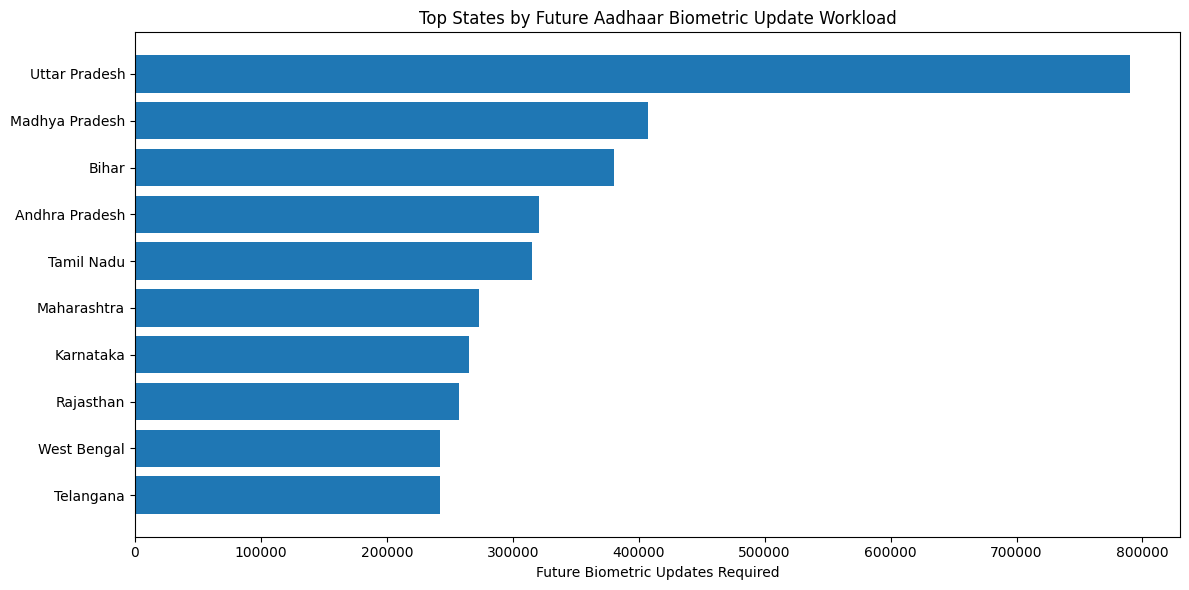

In [43]:
plt.figure(figsize=(12,6))
plt.barh(workload_state["state"].head(10), workload_state["children_needing_updates"].head(10))
plt.xlabel("Future Biometric Updates Required")
plt.title("Top States by Future Aadhaar Biometric Update Workload")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [44]:
district_children = (
    df.groupby(["state","district"])["demo_age_5_17"]
      .sum()
      .reset_index(name="child_aadhaar_activity")
      .sort_values("child_aadhaar_activity")
)

district_children.head(15)


,state,district,child_aadhaar_activity
1,Andaman & Nicobar Islands,Nicobars,0
1053,West Bengal,South Twenty Four Parganas,0
1075,odisha,Gajapati,0
1076,west Bengal,South 24 Parganas,0
394,Karnataka,Bijapur(KAR),0
998,Uttaranchal,Tehri Garhwal,0
1007,West Bangal,South 24 Parganas,0
1003,WESTBENGAL,HOOGHLY,0
1009,West Bengal,Bally Jagachha,0
863,Telangana,Medchalâmalkajgiri,0


In [45]:
district_dependency = (
    df.groupby(["state","district"])
      .agg(children=("demo_age_5_17","sum"), adults=("demo_age_17_","sum"))
      .reset_index()
)

district_dependency["dependency_ratio"] = district_dependency["children"] / (district_dependency["adults"] + 1e-9)

district_dependency.sort_values("dependency_ratio", ascending=False).head(10)


,state,district,children,adults,dependency_ratio
919,Uttar Pradesh,Chandauli *,1,0,1.000000e+09
574,Manipur,Kangpokpi,2,1,2.000000e+00
317,Jammu & Kashmir,Leh (ladakh),4,3,1.333333e+00
59,Arunachal Pradesh,Leparada,8,15,5.333333e-01
903,Uttar Pradesh,Baghpat *,1,2,5.000000e-01
58,Arunachal Pradesh,Kurung Kumey,106,229,4.628821e-01
328,Jammu and Kashmir,Budgam,5738,12884,4.453586e-01
10,Andhra Pradesh,Ananthapur,9092,20934,4.343174e-01
302,Himachal Pradesh,Lahul and Spiti,70,163,4.294479e-01
173,Chhattisgarh,Dantewada,699,1699,4.114185e-01


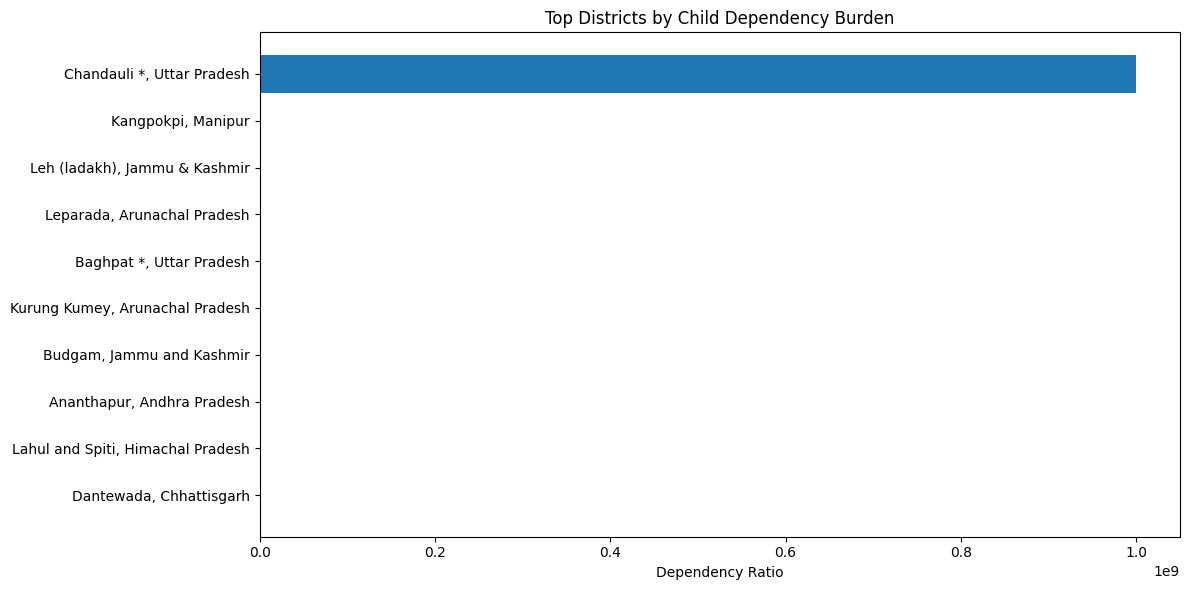

In [46]:
top_dep = district_dependency.sort_values("dependency_ratio", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.barh(top_dep["district"] + ", " + top_dep["state"], top_dep["dependency_ratio"])
plt.xlabel("Dependency Ratio")
plt.title("Top Districts by Child Dependency Burden")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [47]:
welfare_targets = (
    df.groupby(["state","district"])
      .agg(child_share=("child_share","mean"), adult_change=("adult_change","mean"))
      .reset_index()
)

targets = welfare_targets[
    (welfare_targets["child_share"] > 0.25) &
    (welfare_targets["adult_change"] < -5)
]

targets.head(10)


,state,district,child_share,adult_change
328,Jammu and Kashmir,Budgam,0.321198,-10.121008
574,Manipur,Kangpokpi,0.666667,-32.333333
862,Telangana,Medchal?malkajgiri,0.299571,-29.363636
903,Uttar Pradesh,Baghpat *,0.333333,-21.000000
919,Uttar Pradesh,Chandauli *,1.000000,-46.000000


In [48]:
healthcare = (
    df.groupby("state")["demo_age_5_17"]
      .sum()
      .reset_index(name="child_population_proxy")
      .sort_values("child_population_proxy", ascending=False)
)

healthcare.head(10)


,state,child_population_proxy
50,Uttar Pradesh,790308
30,Madhya Pradesh,407098
6,Bihar,380023
2,Andhra Pradesh,321143
47,Tamil Nadu,315638
31,Maharashtra,273322
25,Karnataka,264981
45,Rajasthan,257224
57,West Bengal,242549
48,Telangana,242259


In [49]:
service_access = (
    df.groupby(["state","district"])["total_population_proxy"]
      .mean()
      .reset_index(name="avg_monthly_activity")
      .sort_values("avg_monthly_activity")
)

service_access.head(10)


,state,district,avg_monthly_activity
317,Jammu & Kashmir,Leh (ladakh),0.777778
163,Chandigarh,Rupnagar,0.952381
622,Nagpur,Near Uday nagar NIT garden,1.000000
1,Andaman & Nicobar Islands,Nicobars,1.000000
636,Odisha,Bhadrak(R),1.000000
632,Odisha,Balianta,1.000000
676,Orissa,Baudh,1.000000
1053,West Bengal,South Twenty Four Parganas,1.000000
691,Orissa,Khorda,1.000000
530,Maharashtra,Dist : Thane,1.000000


In [50]:
urban_pressure = (
    df.groupby(["state","district"])
      .agg(
          adult_inflow=("adult_change","mean"),
          activity=("total_population_proxy","mean")
      )
      .reset_index()
)

urban_pressure = urban_pressure.sort_values("adult_inflow", ascending=False)

urban_pressure.head(10)


,state,district,adult_inflow,activity
220,Delhi,North East Delhi,75.709443,341.762712
567,Manipur,Bishnupur,60.983553,138.338816
184,Chhattisgarh,Kawardha,37.969309,171.355499
578,Manipur,Thoubal,37.483232,90.310976
1061,West Bengal,Uttar Dinajpur,27.486522,119.413168
533,Maharashtra,Gondiya,19.634783,55.320000
519,Maharashtra,Aurangabad,17.090284,44.462310
197,Chhattisgarh,Rajnandgaon,16.520231,122.310487
564,Maharashtra,Washim,16.474217,49.607735
186,Chhattisgarh,Kondagaon,16.022764,100.754472


In [51]:
anomaly_districts = anomalies.merge(
    df[["pincode","state","district"]].drop_duplicates(),
    on="pincode",
    how="left"
)

anomaly_districts.groupby(["state","district"]).size().sort_values(ascending=False).head(10)


state             district             
Tamil Nadu        Tirunelveli              3
Andhra Pradesh    Hyderabad                2
Telangana         Hyderabad                2
Andhra Pradesh    Alluri Sitharama Raju    1
Jharkhand         Deoghar                  1
Kerala            Kottayam                 1
Chhattisgarh      Gariyaband               1
Himachal Pradesh  Una                      1
Madhya Pradesh    Narmadapuram             1
                  Anuppur                  1
dtype: int64

In [52]:
df_sorted = df.sort_values(["pincode","date"])
df_sorted["shock"] = df_sorted.groupby("pincode")["adult_change"].diff()

disasters = df_sorted[df_sorted["shock"] < -500]

disasters.head(10)


,date,state,district,pincode,demo_age_5_17,demo_age_17_,dependency_ratio,adult_change,total_population_proxy,child_share,shock
175,2025-09-01,Delhi,Central Delhi,110002,9,18,0.500000,-696.0,27,0.333333,-696.0
273,2025-09-01,Delhi,South Delhi,110003,0,7,0.000000,-564.0,7,0.000000,-564.0
491,2025-09-01,Delhi,Central Delhi,110005,7,49,0.142857,-2531.0,56,0.125000,-2531.0
584,2025-07-01,Delhi,North Delhi,110006,245,1925,0.127273,-674.0,2170,0.112903,-674.0
585,2025-09-01,Delhi,North Delhi,110006,5,44,0.113636,-1881.0,49,0.102041,-1207.0
684,2025-06-01,Delhi,North Delhi,110007,120,1358,0.088365,-617.0,1478,0.081191,-617.0
687,2025-09-01,Delhi,North Delhi,110007,4,34,0.117647,-1367.0,38,0.105263,-1410.0
784,2025-06-01,Delhi,Central Delhi,110008,158,1542,0.102464,-1650.0,1700,0.092941,-1650.0
786,2025-09-01,Delhi,Central Delhi,110008,8,58,0.137931,-1484.0,66,0.121212,-1484.0
883,2025-07-01,Delhi,North West Delhi,110009,116,1175,0.098723,-366.0,1291,0.089853,-561.0


In [53]:
workforce = (
    df.groupby("state")["demo_age_17_"]
      .sum()
      .reset_index(name="adult_activity")
      .sort_values("adult_activity", ascending=False)
)

workforce.head(10)


,state,adult_activity
50,Uttar Pradesh,7752020
31,Maharashtra,4781280
6,Bihar,4434327
57,West Bengal,3629623
45,Rajasthan,2560391
30,Madhya Pradesh,2505840
2,Andhra Pradesh,1974362
47,Tamil Nadu,1896590
9,Chhattisgarh,1840227
18,Gujarat,1615853


In [54]:
adult_activity = (
    df.groupby(["state","district"])["demo_age_17_"]
      .sum()
      .reset_index(name="adult_aadhaar_activity")
)

adult_activity.sort_values("adult_aadhaar_activity").head(10)


,state,district,adult_aadhaar_activity
919,Uttar Pradesh,Chandauli *,0
394,Karnataka,Bijapur(KAR),1
429,Karnataka,Udupi *,1
530,Maharashtra,Dist : Thane,1
326,Jammu and Kashmir,Bandipur,1
942,Uttar Pradesh,Jyotiba Phule Nagar *,1
318,Jammu & Kashmir,Pulwama,1
921,Uttar Pradesh,Chitrakoot *,1
705,Orissa,Sundergarh,1
622,Nagpur,Near Uday nagar NIT garden,1


In [55]:
ineq = (
    df.groupby(["state","district"])
      .agg(
          dependency=("dependency_ratio","mean"),
          outflow=("adult_change","mean"),
          child_share=("child_share","mean")
      )
      .reset_index()
)

ineq["inequality_index"] = (
    ineq["dependency"]*0.4 +
    (-ineq["outflow"])*0.4 +
    ineq["child_share"]*0.2
)

ineq.sort_values("inequality_index", ascending=False).head(10)


,state,district,dependency,outflow,child_share,inequality_index
919,Uttar Pradesh,Chandauli *,1.000000e+09,-46.000000,1.000000,4.000000e+08
574,Manipur,Kangpokpi,6.666667e+08,-32.333333,0.666667,2.666667e+08
317,Jammu & Kashmir,Leh (ladakh),4.444444e+08,-4.333333,0.444444,1.777778e+08
59,Arunachal Pradesh,Leparada,3.809524e+08,-4.952381,0.333333,1.523810e+08
903,Uttar Pradesh,Baghpat *,3.333333e+08,-21.000000,0.333333,1.333333e+08
300,Himachal Pradesh,Lahaul and Spiti,2.745098e+08,-0.137255,0.284314,1.098039e+08
596,Mizoram,Khawzawl,2.692308e+08,-4.000000,0.288462,1.076923e+08
10,Andhra Pradesh,Ananthapur,2.513158e+08,-3.249836,0.335223,1.005263e+08
302,Himachal Pradesh,Lahul and Spiti,2.397661e+08,-0.286550,0.265692,9.590643e+07
56,Arunachal Pradesh,Kamle,2.244898e+08,-0.163265,0.290597,8.979592e+07


In [56]:
smart_city_candidates = district_migration[district_migration["avg_monthly_adult_change"] > 15]
smart_city_candidates.head(10)


,state,district,avg_monthly_adult_change,migration_category
220,Delhi,North East Delhi,75.709443,High In-Migration
567,Manipur,Bishnupur,60.983553,High In-Migration
184,Chhattisgarh,Kawardha,37.969309,High In-Migration
578,Manipur,Thoubal,37.483232,High In-Migration
1061,West Bengal,Uttar Dinajpur,27.486522,High In-Migration
533,Maharashtra,Gondiya,19.634783,High In-Migration
519,Maharashtra,Aurangabad,17.090284,High In-Migration
197,Chhattisgarh,Rajnandgaon,16.520231,High In-Migration
564,Maharashtra,Washim,16.474217,High In-Migration
186,Chhattisgarh,Kondagaon,16.022764,High In-Migration


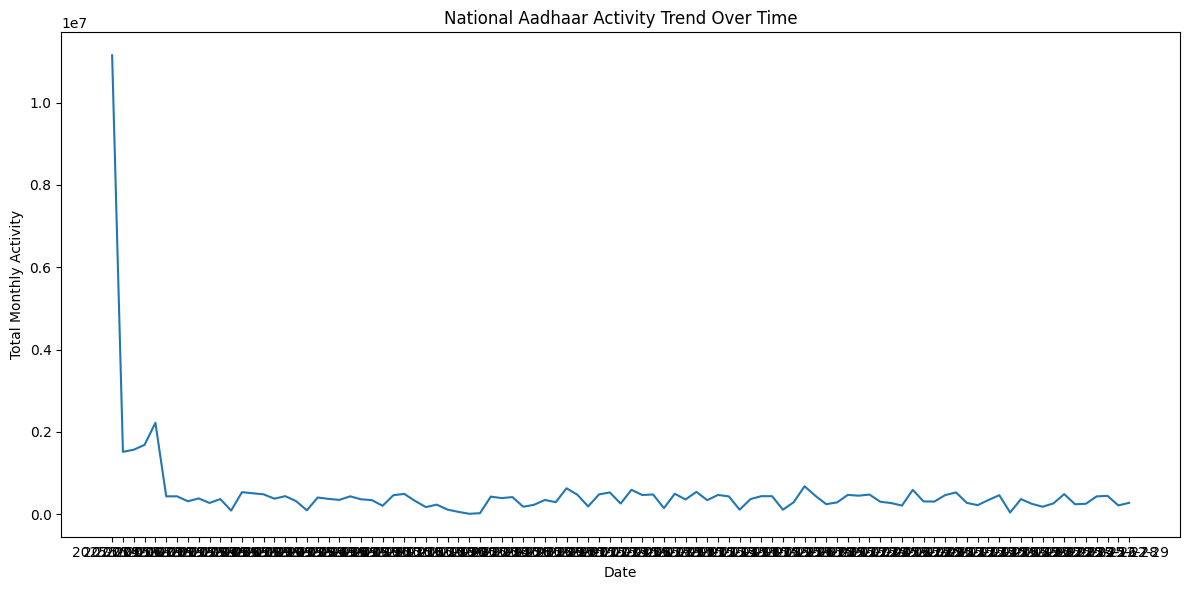

In [57]:
monthly_activity = (
    df.groupby("date")["total_population_proxy"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(monthly_activity["date"], monthly_activity["total_population_proxy"])
plt.title("National Aadhaar Activity Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Monthly Activity")
plt.tight_layout()
plt.show()
